Forma de la imagen: (759, 759, 3)
Tipo de datos: uint8
Dimensiones: Alto=759, Ancho=759, Canales=3


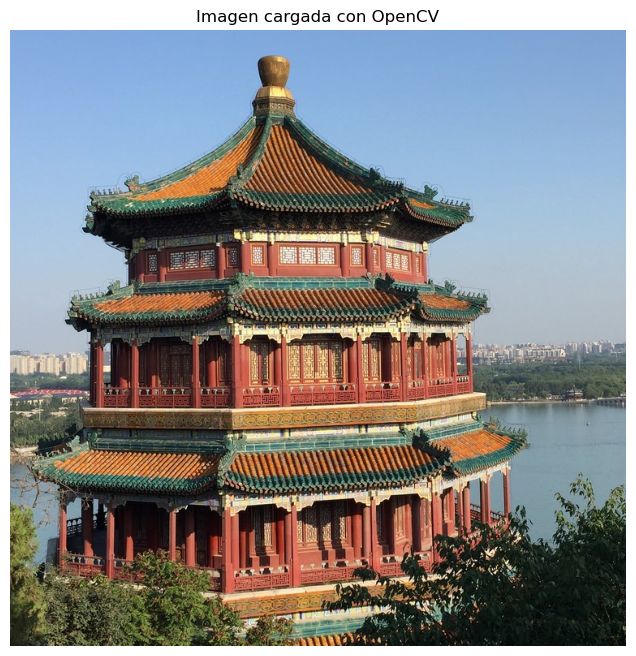

[[[222 170 130]
  [222 170 130]
  [222 170 130]
  ...
  [212 163 125]
  [212 163 125]
  [212 163 125]]

 [[222 170 130]
  [222 170 130]
  [222 170 130]
  ...
  [213 164 126]
  [212 163 125]
  [212 163 125]]

 [[222 170 130]
  [222 170 130]
  [222 170 130]
  ...
  [213 164 126]
  [212 163 125]
  [212 163 125]]

 ...

 [[ 17  24  21]
  [ 19  26  23]
  [ 26  33  30]
  ...
  [  9  13   8]
  [  8  14   9]
  [  5  11   6]]

 [[ 16  23  20]
  [ 26  33  30]
  [ 21  28  25]
  ...
  [ 10  14   9]
  [  7  13   8]
  [  8  14   9]]

 [[ 16  21  19]
  [ 22  27  25]
  [ 22  27  25]
  ...
  [ 11  15  10]
  [  7  11   6]
  [ 11  15  10]]]


In [13]:
import cv2
import matplotlib.pyplot as plt

# Leer la imagen con OpenCV
imagen = cv2.imread('Datos/Imagen.png')

# Mostrar información de la imagen
print(f"Forma de la imagen: {imagen.shape}")
print(f"Tipo de datos: {imagen.dtype}")
print(f"Dimensiones: Alto={imagen.shape[0]}, Ancho={imagen.shape[1]}, Canales={imagen.shape[2]}")

# Visualizar la imagen
# Nota: OpenCV lee en BGR, necesitamos convertir a RGB para matplotlib
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(imagen_rgb)
plt.axis('off')
plt.title('Imagen cargada con OpenCV')
plt.show()


print(imagen)

Dimensiones originales: 759 x 759 x 3
Forma de los pixeles: (576081, 3)
Total de pixeles: 576081
[[222 170 130]
 [222 170 130]
 [222 170 130]
 [222 170 130]
 [222 170 130]]

Aplicando K-means con k=2...
Forma de las etiquetas: (576081,)
[0 0 0 0 0 0 0 0 0 0]
Clusters encontrados: 2
Centros de los clusters: (2, 3)

--- Diferencia entre imágenes ---
Norma de Frobenius: 49951.04
Norma de Frobenius normalizada: 37.9964


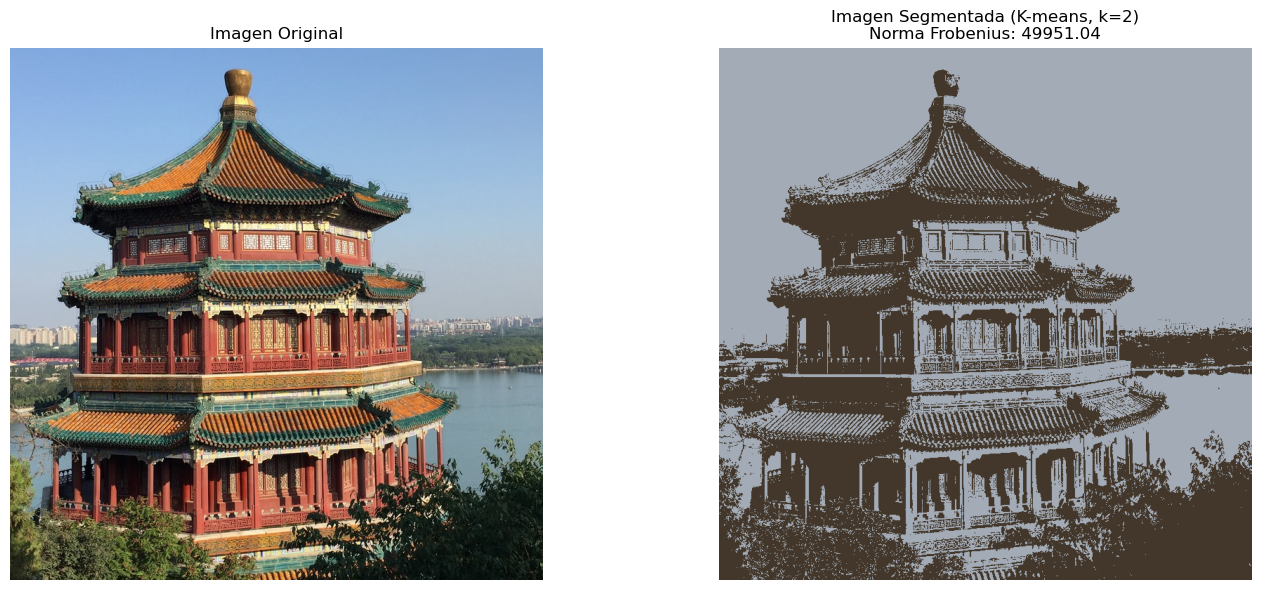

In [14]:
from sklearn.cluster import KMeans
import numpy as np

# Obtener las dimensiones de la imagen
alto, ancho, canales = imagen.shape
print(f"Dimensiones originales: {alto} x {ancho} x {canales}")

# Reshape: convertir la imagen de (alto, ancho, canales) a (alto*ancho, canales)
# Cada fila será un pixel con sus valores BGR
pixeles = imagen.reshape(-1, canales)
print(f"Forma de los pixeles: {pixeles.shape}")
print(f"Total de pixeles: {pixeles.shape[0]}")
print(pixeles[:5])  # Mostrar los primeros 5 pixeles para verificar

# Aplicar K-means con k=20
k = 2
print(f"\nAplicando K-means con k={k}...")
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
etiquetas = kmeans.fit_predict(pixeles)

print(f"Forma de las etiquetas: {etiquetas.shape}")
print(etiquetas[:10])  # Mostrar las primeras 10 etiquetas para verificar
print(f"Clusters encontrados: {len(set(etiquetas))}")
print(f"Centros de los clusters: {kmeans.cluster_centers_.shape}")

# Reconstruir la imagen usando los centros de los clusters
imagen_segmentada = kmeans.cluster_centers_[etiquetas]
imagen_segmentada = imagen_segmentada.reshape(alto, ancho, canales).astype('uint8')

# Calcular la norma de Frobenius entre ambas imágenes
# Primero calculamos la diferencia y luego la norma de Frobenius
diferencia = imagen.astype(float) - imagen_segmentada.astype(float)
norma_frobenius = np.linalg.norm(diferencia.flatten())  # Aplanamos para calcular la norma
print(f"\n--- Diferencia entre imágenes ---")
print(f"Norma de Frobenius: {norma_frobenius:.2f}")
print(f"Norma de Frobenius normalizada: {norma_frobenius / np.sqrt(alto * ancho * canales):.4f}")

# Visualizar la imagen original y la segmentada
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagen Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(imagen_segmentada, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Imagen Segmentada (K-means, k={k})\nNorma Frobenius: {norma_frobenius:.2f}')
axes[1].axis('off')

plt.tight_layout()
plt.show()